# Model Performance in Unusual vs Normal Years — PEP725 Fruit Trees

**Question**: do process-based and ML phenology models perform equally well in
climatologically unusual years (very early or very late bloom) as in normal years?

**Approach**:
1. Classify each year as *early*, *late*, or *normal* using a network-level
   z-score across all PEP725 fruit tree species.
2. Train on all normal years; test on all unusual years.
3. Compare Utah+GDD, ChillingDays+GDD, RandomForest, LSTM, and Hybrid.

## Config

In [ ]:
OBS_KEY       = 'BBCH_60'
YEAR_MIN      = 1986
YEAR_MAX      = 2024

# Anomaly detection (applied to the raw PEP725 fruit tree network)
MIN_CLIM_YEARS = 5     # minimum site-years to compute a reliable climatology
NET_Z_THRESH   = 0.5   # |mean_z| > this → unusual year

# Dataset to use for model fitting / evaluation (aggregated, cache-compatible)
DATASET_KEY   = 'PEP725_fruit_trees'

# Process-based model optimisation budget
OPT_MAX_TIME  = 60.0   # seconds per phase (hard cap)
OPT_MAX_STEPS = 400    # NLopt evaluations per phase

# Neural model training
DL_KW = dict(
    batch_size               = 512,
    num_epochs               = 1000,
    optimizer                = 'adam',
    optimizer_kwargs         = dict(lr=1e-3, weight_decay=1e-4),
    scheduler_step_size      = 100,
    scheduler_decay          = 0.9,
    early_stopping           = True,
    early_stopping_patience  = 10,
    early_stopping_min_delta = 1e-3,
    early_stopping_rerun     = False,
    val_period               = 10,
)

## 1. Classify years as unusual / normal

Load the raw (non-aggregated) PEP725 fruit tree network, compute a
site-level bloom DOY climatology, z-score each observation against its own
site history, then take the observation-count-weighted mean z across all
species for each year.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from pysephone.data.pep725.source import PEP725Source
from pysephone.dataset.observations import Observations
from pysephone.dataset.preprocessing.pep725 import get_pep725_dataframes
from pysephone.constants import KEY_OBS_TYPE, KEY_OBSERVATIONS, KEY_SPECIES_ID

_SRC = PEP725Source.KEY

FRUIT_TREE_SPECIES = [
    (_SRC, 220), (_SRC, 227), (_SRC, 202), (_SRC, 782),
    (_SRC, 107), (_SRC, 222), (_SRC, 205), (_SRC, 225), (_SRC, 123),
]

raw_data = PEP725Source().get_data({})
dfs_raw  = get_pep725_dataframes(
    raw_data,
    filter_on_species=FRUIT_TREE_SPECIES,
    filter_on_observation_types=[OBS_KEY],
    filter_on_years=list(range(YEAR_MIN, YEAR_MAX + 1)),
    remove_outliers=False,
    datetime_observations=True,
)
obs_raw    = Observations(dfs_raw['data'], dfs_raw['locations'],
                          species_names=dfs_raw.get('species_names'))
id_to_name = {sid: name for (src, sid), name in obs_raw.species_names.items()}

df_raw = obs_raw._df_y.xs(OBS_KEY, level=KEY_OBS_TYPE).copy()
df_raw['doy'] = df_raw[KEY_OBSERVATIONS].dt.dayofyear
df_raw = df_raw.reset_index()
df_raw = df_raw.merge(obs_raw._df_y_loc.reset_index(), on=['src', 'loc_id'], how='left')
df_raw['species_name'] = df_raw[KEY_SPECIES_ID].map(id_to_name)

# Site climatology
clim = (
    df_raw.groupby(['species_name', 'loc_id'])['doy']
          .agg(clim_mean='mean', clim_std='std', n_clim='count')
          .reset_index()
)
clim.loc[clim['n_clim'] < MIN_CLIM_YEARS, ['clim_mean', 'clim_std']] = np.nan
df_raw = df_raw.merge(clim, on=['species_name', 'loc_id'], how='left')
df_raw['anom_z'] = (df_raw['doy'] - df_raw['clim_mean']) / df_raw['clim_std']

# Network-level weighted mean z per year
yr_sp_z = (
    df_raw[df_raw['anom_z'].notna()]
          .groupby(['year', 'species_name'])['anom_z']
          .agg(mean_z='mean', n='count')
          .reset_index()
)
network_z = (
    yr_sp_z.groupby('year')
           .apply(lambda g: np.average(g['mean_z'], weights=g['n']),
                  include_groups=False)
           .rename('network_z')
)

# Classify
year_type = {}
for yr, z in network_z.items():
    if   z < -NET_Z_THRESH: year_type[int(yr)] = 'early'
    elif z >  NET_Z_THRESH: year_type[int(yr)] = 'late'
    else:                   year_type[int(yr)] = 'normal'

unusual_early = sorted(y for y, t in year_type.items() if t == 'early')
unusual_late  = sorted(y for y, t in year_type.items() if t == 'late')
normal_years  = sorted(y for y, t in year_type.items() if t == 'normal')

print(f'Normal years  ({len(normal_years)}):         {normal_years}')
print(f'Unusual early ({len(unusual_early)}): {unusual_early}')
print(f'Unusual late  ({len(unusual_late)}):  {unusual_late}')

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 46044.73it/s]


Normal years  (19):         [1988, 1991, 1992, 1993, 1994, 1995, 1997, 1999, 2000, 2001, 2003, 2004, 2005, 2008, 2009, 2010, 2012, 2015, 2016]
Unusual early (7): [1989, 1990, 1998, 2002, 2007, 2011, 2014]
Unusual late  (5):  [1986, 1987, 1996, 2006, 2013]


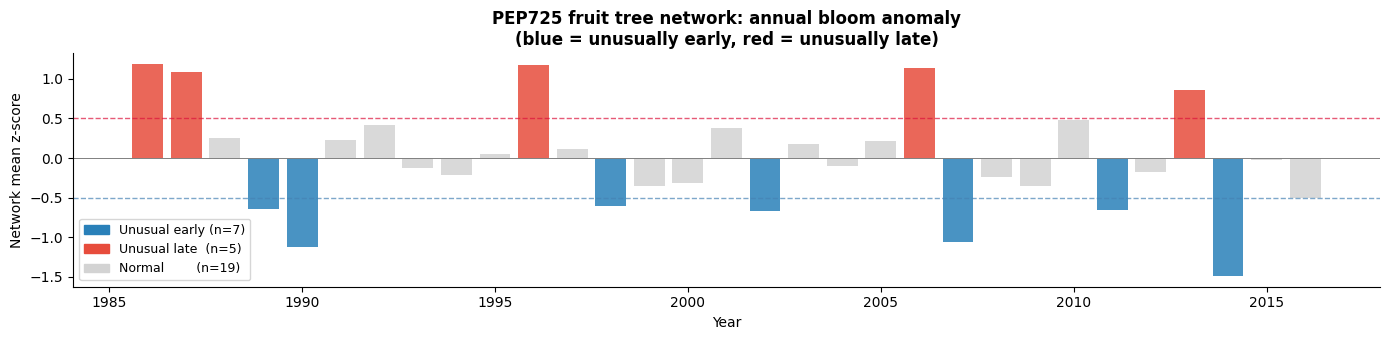

In [3]:
fig, ax = plt.subplots(figsize=(14, 3.5))
colors = [{'early': '#2980b9', 'late': '#e74c3c', 'normal': 'lightgrey'}[year_type.get(int(yr), 'normal')]
          for yr in network_z.index]
ax.bar(network_z.index, network_z.values, color=colors, width=0.8, alpha=0.85)
ax.axhline( NET_Z_THRESH, color='crimson',   lw=1, ls='--', alpha=0.7)
ax.axhline(-NET_Z_THRESH, color='steelblue', lw=1, ls='--', alpha=0.7)
ax.axhline(0, color='grey', lw=0.7)
ax.set_xlabel('Year'); ax.set_ylabel('Network mean z-score')
ax.set_title('PEP725 fruit tree network: annual bloom anomaly\n'
             '(blue = unusually early, red = unusually late)', fontweight='bold')
patches = [
    mpatches.Patch(color='#2980b9', label=f'Unusual early (n={len(unusual_early)})'),
    mpatches.Patch(color='#e74c3c', label=f'Unusual late  (n={len(unusual_late)})'),
    mpatches.Patch(color='lightgrey', label=f'Normal        (n={len(normal_years)})'),
]
ax.legend(handles=patches, fontsize=9)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout(); plt.show()

## 2. Load aggregated model dataset

Use `Dataset.load` so that the existing OpenMeteo temperature cache (built
with grid aggregation) is reused without re-downloading.

In [4]:
from pysephone.dataset.dataset import Dataset
from pysephone.dataset.util.calendar import Calendar
from pysephone.dataset.util.openmeteo import OpenMeteoFeatures

cal      = Calendar(default_start='10-01', default_length=365)
features = OpenMeteoFeatures(calendar=cal)

ds_all = Dataset.load(DATASET_KEY, calendar=cal, feature_providers=[features])
print(f'Dataset: {len(ds_all)} samples | '
      f'years {min(ds_all.years)}–{max(ds_all.years)} | '
      f'locations {len(ds_all.locations)} | '
      f'species {len(ds_all.species)}')

Checking for missing PEP725 data: 100%|██████████| 174/174 [00:00<00:00, 42713.85it/s]


Dataset: 40317 samples | years 1986–2016 | locations 2825 | species 9


## 3. Define train / test splits

- **Train**: all normal years (in-sample performance = baseline)
- **Test**: all unusual years (early + late)

In [5]:
def make_splits(ds):
    available = sorted(ds.years)
    trn = [y for y in available if year_type.get(y) == 'normal']
    tst = [y for y in available if year_type.get(y) in ('early', 'late')]
    return ds.select_years(trn), ds.select_years(tst)

ds_trn, ds_tst = make_splits(ds_all)
n_early = sum(1 for y in ds_tst.years if year_type.get(y) == 'early')
n_late  = sum(1 for y in ds_tst.years if year_type.get(y) == 'late')
print(f'Train: {len(ds_trn):5d} samples | {len(ds_trn.years)} normal years')
print(f'Test:  {len(ds_tst):5d} samples | {n_early} early years, {n_late} late years')

Train: 24774 samples | 19 normal years
Test:  15543 samples | 7 early years, 5 late years


## 4. Fit models

Fit on normal years only.  Process-based models are optimised with two-phase
NLopt (GN_DIRECT → LN_COBYLA).  Neural models (LSTM, Hybrid) are trained
with PyTorch using BCE against a soft step-function target.

In [ ]:
import torch
from pysephone.models.cf           import UtahGDDModel, ChillingDaysGDDModel
from pysephone.models.random_forest import RandomForestModel
from pysephone.models.lstm          import LSTMModel
from pysephone.models.hybrid        import HybridModel

target_fn = lambda s: s['observations'][OBS_KEY]
device    = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

OPT_KW = dict(opt_max_time=OPT_MAX_TIME, opt_max_steps=OPT_MAX_STEPS)

fitted = {}

# ── Process-based ────────────────────────────────────────────────────────────
PB_SPECS = [
    ('Utah+GDD',         UtahGDDModel,        dict(threshold_c=50.0, threshold_f=200.0, t_base=4.0, **OPT_KW)),
    ('ChillingDays+GDD', ChillingDaysGDDModel, dict(threshold_c=50.0, threshold_f=200.0, t_chill=7.2, t_base=4.0,
                                                     params_opt=['th_c', 'th_f', 't_base'], **OPT_KW)),
]
for name, cls, kwargs in PB_SPECS:
    print(f'Fitting {name} ...', end=' ', flush=True)
    model, _ = cls.fit(target_fn=target_fn, dataset=ds_trn, model_kwargs=kwargs)
    fitted[name] = model
    print(f'done  {model.params}')

# ── Random Forest ────────────────────────────────────────────────────────────
print('Fitting RandomForest ...', end=' ', flush=True)
rf, _ = RandomForestModel.fit(target_fn=target_fn, dataset=ds_trn)
fitted['RandomForest'] = rf
print('done')

# ── LSTM ─────────────────────────────────────────────────────────────────────
print(f'Fitting LSTM ...')
lstm, _ = LSTMModel.fit(
    target_fn=target_fn, dataset=ds_trn,
    model_kwargs=dict(
        data_keys=['temperature_2m_mean', 'daylight_duration'],
        hidden_size=64, num_layers=2,
    ),
    **DL_KW, device=device, verbose=True,
)
fitted['LSTM'] = lstm

# ── Hybrid ───────────────────────────────────────────────────────────────────
print(f'Fitting Hybrid ...')
hybrid, _ = HybridModel.fit(
    target_fn=target_fn, dataset=ds_trn,
    model_kwargs=dict(
        data_keys=['temperature_2m_mean', 'daylight_duration'],
    ),
    **DL_KW, device=device, verbose=True,
)
fitted['Hybrid'] = hybrid

Device: cuda
Fitting Utah+GDD ... done  {'th_c': 55.844775587157045, 'th_f': 109.41429465864306, 't_base': 4.231917577136908}
Fitting ChillingDays+GDD ... done  {'th_c': 29.861276721157093, 'th_f': 334.0272549409166, 't_chill': 7.2, 't_base': 0.9197220863066519}
Fitting RandomForest ... done
Fitting LSTM ...


LSTMModel epoch [    1/1000] lr=1.00e-03 loss=0.58610: 100%|██████████| 35/35 [00:01<00:00, 33.61it/s]
LSTMModel epoch [    2/1000] lr=1.00e-03 loss=0.21501: 100%|██████████| 35/35 [00:00<00:00, 56.04it/s]
LSTMModel epoch [    3/1000] lr=1.00e-03 loss=0.15666: 100%|██████████| 35/35 [00:00<00:00, 55.67it/s]
LSTMModel epoch [    4/1000] lr=1.00e-03 loss=0.14306: 100%|██████████| 35/35 [00:00<00:00, 54.57it/s]
LSTMModel epoch [    5/1000] lr=1.00e-03 loss=0.13266: 100%|██████████| 35/35 [00:00<00:00, 57.09it/s]
LSTMModel epoch [    6/1000] lr=1.00e-03 loss=0.13208: 100%|██████████| 35/35 [00:00<00:00, 58.01it/s]
LSTMModel epoch [    7/1000] lr=1.00e-03 loss=0.12999: 100%|██████████| 35/35 [00:00<00:00, 56.97it/s]
LSTMModel epoch [    8/1000] lr=1.00e-03 loss=0.12756: 100%|██████████| 35/35 [00:00<00:00, 56.73it/s]
LSTMModel epoch [    9/1000] lr=1.00e-03 loss=0.12730: 100%|██████████| 35/35 [00:00<00:00, 55.67it/s]
LSTMModel epoch [   10/1000] lr=1.00e-03 loss=0.12635: 100%|██████████| 3

Fitting Hybrid ...


HybridModel epoch [    1/1000] lr=1.00e-03 loss=0.63473: 100%|██████████| 40/40 [00:00<00:00, 68.34it/s]
HybridModel epoch [    2/1000] lr=1.00e-03 loss=0.56423: 100%|██████████| 40/40 [00:00<00:00, 82.32it/s]
HybridModel epoch [    3/1000] lr=1.00e-03 loss=0.54611: 100%|██████████| 40/40 [00:00<00:00, 81.07it/s]
HybridModel epoch [    4/1000] lr=1.00e-03 loss=0.51000: 100%|██████████| 40/40 [00:00<00:00, 82.08it/s]
HybridModel epoch [    5/1000] lr=1.00e-03 loss=0.50949: 100%|██████████| 40/40 [00:00<00:00, 83.13it/s]
HybridModel epoch [    6/1000] lr=1.00e-03 loss=0.48882: 100%|██████████| 40/40 [00:00<00:00, 83.81it/s]
HybridModel epoch [    7/1000] lr=1.00e-03 loss=0.50097: 100%|██████████| 40/40 [00:00<00:00, 84.71it/s]
HybridModel epoch [    8/1000] lr=1.00e-03 loss=0.48666: 100%|██████████| 40/40 [00:00<00:00, 87.88it/s]
HybridModel epoch [    9/1000] lr=1.00e-03 loss=0.47375: 100%|██████████| 40/40 [00:00<00:00, 85.18it/s]
HybridModel epoch [   10/1000] lr=1.00e-03 loss=0.47390

## 5. Evaluate per year type

Run each model on both the training set (normal years, in-sample) and the
test set (unusual years, out-of-sample), then split predictions by year type.

In [ ]:
from pysephone.evaluation.regression import SingleTargetRegression

def metrics_by_year_type(df_pred, label):
    df = df_pred.copy()
    df['year_type'] = df['year'].map(lambda y: year_type.get(int(y), 'unknown'))
    rows = []
    for yt in ('normal', 'early', 'late'):
        sub = df[df['year_type'] == yt]
        if sub.empty:
            continue
        errs = sub['error'].values
        rows.append({
            'year_type':  yt,
            'split':      label,
            'n_years':    sub['year'].nunique(),
            'n_samples':  len(sub),
            'MAE':        float(np.mean(np.abs(errs))),
            'RMSE':       float(np.sqrt(np.mean(errs**2))),
            'Bias':       float(np.mean(errs)),
        })
    return pd.DataFrame(rows).set_index('year_type')


eval_results  = {}
slice_metrics = {}

for name, model in fitted.items():
    result = SingleTargetRegression.run(
        model=model,
        dataset_train=ds_trn,
        dataset_test=ds_tst,
        target_fn=target_fn,
        run_name=f'{name.lower().replace("+","_").replace(" ","_")}_fruit_trees',
    )
    eval_results[name]  = result
    slice_metrics[name] = pd.concat([
        metrics_by_year_type(result.df_train, 'train'),
        metrics_by_year_type(result.df_test,  'test'),
    ])

print('Evaluation complete.')

In [ ]:
rows = []
for model_name, sm in slice_metrics.items():
    for yt, row in sm.iterrows():
        rows.append({
            'Model':      model_name,
            'Split':      row['split'],
            'Year type':  yt,
            'N years':    int(row['n_years']),
            'N samples':  int(row['n_samples']),
            'MAE':        round(row['MAE'],  1),
            'RMSE':       round(row['RMSE'], 1),
            'Bias':       round(row['Bias'], 1),
        })
df_summary = pd.DataFrame(rows).set_index(['Model', 'Split', 'Year type'])
display(df_summary)

## 6. Comparison plots

Bar charts of MAE per model, split by year type.

In [ ]:
MODEL_ORDER = ['Utah+GDD', 'ChillingDays+GDD', 'RandomForest', 'LSTM', 'Hybrid']
YT_COLORS   = {'normal': '#95a5a6', 'early': '#2980b9', 'late': '#e74c3c'}
YT_ORDER    = ['normal', 'early', 'late']

fig, ax = plt.subplots(figsize=(13, 5))
ax.set_title('MAE (days) by model and year type — all PEP725 fruit trees',
             fontsize=12, fontweight='bold')

x      = np.arange(len(MODEL_ORDER))
width  = 0.25
offset = -(len(YT_ORDER) - 1) / 2 * width

for i, yt in enumerate(YT_ORDER):
    maes = []
    for m in MODEL_ORDER:
        sm = slice_metrics.get(m, pd.DataFrame())
        maes.append(sm.loc[yt, 'MAE'] if yt in sm.index else np.nan)
    bars = ax.bar(x + offset + i * width, maes, width,
                  label=yt, color=YT_COLORS[yt], alpha=0.85)
    for bar, val in zip(bars, maes):
        if not np.isnan(val):
            ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
                    f'{val:.1f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels(MODEL_ORDER, fontsize=9)
ax.set_ylabel('MAE (days)')
ax.legend(title='Year type', fontsize=8)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

## 7. Scatter plots — predicted vs observed

Predictions coloured by year type.  Systematic over/under-prediction in
unusual years shows up as a vertical cluster offset.

In [ ]:
n_models = len(MODEL_ORDER)
fig, axes = plt.subplots(1, n_models, figsize=(4.5 * n_models, 4.5))
fig.suptitle('Predicted vs observed — all PEP725 fruit trees', fontweight='bold')

for ax, name in zip(axes, MODEL_ORDER):
    result = eval_results[name]
    df = result.df_test.copy()
    df['year_type'] = df['year'].map(lambda y: year_type.get(int(y), 'unknown'))

    for yt in YT_ORDER:
        sub = df[df['year_type'] == yt]
        ax.scatter(sub['observed_doy'], sub['predicted_doy'],
                   c=YT_COLORS[yt], s=18, alpha=0.65, edgecolors='none',
                   label=yt, zorder={'normal': 1, 'early': 3, 'late': 3}[yt])

    lo = min(df['observed_doy'].min(), df['predicted_doy'].min()) - 3
    hi = max(df['observed_doy'].max(), df['predicted_doy'].max()) + 3
    ax.plot([lo, hi], [lo, hi], 'k--', lw=0.8, alpha=0.5)
    ax.set_xlim(lo, hi); ax.set_ylim(lo, hi)
    ax.set_xlabel('Observed DOY', fontsize=9)
    ax.set_ylabel('Predicted DOY', fontsize=9)
    ax.set_title(name, fontsize=9, fontweight='bold')
    ax.set_aspect('equal')
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    if ax is axes[0]:
        ax.legend(fontsize=8, title='Year type')

plt.tight_layout()
plt.show()

## 8. Error distribution by year type

Box plots of prediction error (predicted − observed) grouped by year type.
A systematic bias in unusual years indicates the model has learned patterns
specific to normal climate conditions.

In [ ]:
fig, axes = plt.subplots(1, len(MODEL_ORDER), figsize=(4 * len(MODEL_ORDER), 4),
                          sharey=True)
fig.suptitle('Prediction error by year type — all PEP725 fruit trees', fontweight='bold')

for ax, name in zip(axes, MODEL_ORDER):
    result = eval_results[name]
    df = result.df_test.copy()
    df['year_type'] = df['year'].map(lambda y: year_type.get(int(y), 'unknown'))

    data = [df[df['year_type'] == yt]['error'].values for yt in YT_ORDER]
    bp   = ax.boxplot(data, patch_artist=True, notch=False,
                      medianprops=dict(color='black', lw=1.5))
    for patch, yt in zip(bp['boxes'], YT_ORDER):
        patch.set_facecolor(YT_COLORS[yt])
        patch.set_alpha(0.75)
    ax.axhline(0, color='grey', lw=0.8, ls='--')
    ax.set_xticks(range(1, len(YT_ORDER) + 1))
    ax.set_xticklabels(YT_ORDER, fontsize=9)
    ax.set_title(name, fontsize=9, fontweight='bold')
    if ax is axes[0]:
        ax.set_ylabel('Error (days)', fontsize=9)
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()